In [1]:
%env PYTORCH_ENABLE_MPS_FALLBACK=1

import warnings
warnings.filterwarnings('ignore')

import numpy as np
from matplotlib import pyplot as plt
import lightning as L
from lightning.pytorch.callbacks.early_stopping import EarlyStopping
from torch.utils.data import DataLoader, random_split
import torch
import sys
from functools import partial
import time
sys.path.append("..")
from src.models import NeuralPosteriorEstimator
from src.data.reinfection import AoN, Win, PPI, InH, TwoVi, Mut, BaseReinfectionModel
mps_device = torch.device("mps")
import pandas as pd
import pickle

env: PYTORCH_ENABLE_MPS_FALLBACK=1


In [2]:
N = 2000
# noise = {"distr": "normal", "scale":1}
a = int(N * 0.8)
b = N - a
T = 59
J = 100

#### Objective 

Fit each of the six candidate models to the observed data with NPE. Obtain parameter estimates, compute posterior predictive errors.

To Do:
- Comparative visualization of posterior predictive means
- Plot of parameter estimates (can be placed in the supplement)
- Reconsider how you compute extinction probabilities (might not be possible to do this from the observed cases, you'll need access to the "true" cases

The original paper evaluates predictive power conditioning on second-wave survivals. That is, discarding any simulation that has at least one 0 between days 28 and 35. This approach may be worth a second pass. 

In [3]:
estimates = dict()
predictions = dict()

In [19]:
def acf(x, length=20):
    return np.array([np.corrcoef(x[:-i], x[i:])[0,1]  \
        for i in range(1, length)])

def summarize_sample(sample, components, distribution):
    est = dict()
    m = sample.mean(0)
    q_low = torch.quantile(sample, q=0.05, dim=0)
    q_high = torch.quantile(sample, q=0.95, dim=0)
    _ ,D = sample.shape
    for d in range(D):
        p = components[d]
        print(f"{distribution} Estimate of {p}: {m[d]: .3f} ({q_low[d]:.3f}, {q_high[d]:.3f})")
        est[p] = (m[d].item(), q_low[d].item(), q_high[d].item())
    return est

def mse(d):
    return ((d**2).mean(1) ** 0.5).mean()

def posterior_predictive_checker(sample, simulator, x_o, tag):
    J = len(sample)
    if type(x_o) is torch.Tensor:
        x_o = x_o.numpy()
    ppd = np.empty((J, 59))
    for j in range(J):
        z = sample[j]
        ppd[j] = simulator.simulate(z, seed=j*4)

    # posterior predictive check
    labels = ["Post. Pred. Draw"] + [None for _ in range(J-1)]
    plt.plot(ppd.T, color="tab:blue", label=labels, alpha=0.1)
    plt.plot(ppd.mean(0), color="tab:orange", label="Post. Pred. Mean", linestyle="--")
    plt.plot(x_o, label="Observed", color="k", linestyle="-.")
    plt.xlabel("Day")
    plt.ylabel("Incidence")
    plt.legend()
    plt.savefig(f"figures/posterior_predictive_check_{tag}.png")
    plt.show()
    # residuals
    res = (ppd - x_o).mean(0)
    residual_mean = res.mean()
    # standardized residuals
    var = ((ppd**2).mean(0) - (ppd.mean(0))**2)
    std_res = res / var**0.5
    residual_autocorr = acf(std_res[1:])
    # errors
    errors = ppd - x_o
    total_error = mse(errors)
    second_wave_error = mse(errors[20:36])
    extinction_error = mse(errors[51:59])

    return {"error": (total_error, second_wave_error, extinction_error),
           "residual mean": residual_mean, "residual autocorrelation": residual_autocorr}

In [20]:
def run_experiment(dataset, tag, save_sample=True):
    x_o = dataset.get_observed_data()[0]

    
    prior_sample = dataset.transform_parameters(dataset.theta, inverse=True)
    params = list(dataset.parameters.keys())
    _ = summarize_sample(prior_sample, params, "Prior")

    # construct data loaders
    train_data, val_data = random_split(dataset, [a, b])
    train_loader = DataLoader(train_data, batch_size=400)
    val_loader = DataLoader(val_data, batch_size=b)
    

    # train NPE
    optim = partial(torch.optim.AdamW, lr=0.0005)
    d_theta = dataset.theta.shape[1]
    model = NeuralPosteriorEstimator(d_theta, 59, 4, flow_type="MAF", optimizer=optim)
    callbacks = [EarlyStopping(monitor="val_loss", mode="min", patience=20)]
    trainer = L.Trainer(max_epochs=1000, log_every_n_steps=1, callbacks=callbacks)
    trainer.fit(model, train_loader, val_loader)
    
    # fit to data and sample from the posterior
    torch.manual_seed(1)
    posterior_sample_transformed = model.sample(J, x_o)
    posterior_sample = dataset.transform_parameters(posterior_sample_transformed, inverse=True)
    if save_sample:
        torch.save(posterior_sample, f"results/{tag}_posterior.pt")

    prior_mean = dataset.data[:100].mean(0)

    lab = ["Prior Pred. Draw"] + [None for _ in range(99)]
    plt.plot(dataset.data[:100].T, alpha=0.1, color="tab:blue", label=lab)
    plt.plot(prior_mean, label="Prior Pred. Mean", linestyle="--", color="tab:orange")
    plt.plot(x_o, color="k", label="Observed", linestyle="-.")
    plt.xlabel("Day")
    plt.ylabel("Incidence")
    plt.legend()
    plt.savefig(f"figures/prior_predictive_check_{tag}.png")
    plt.show()


    # labels = ["Post. Pred. Draw"] + [None for _ in range(J-1)]
    # plt.plot(x_o, label="Observed", color="k", linestyle="-.")
    # plt.plot(ppd.mean(0), color="tab:orange", label="Post. Pred. Mean")
    # plt.plot(ppd.T, color="tab:blue", label=labels, alpha=0.1)
    # plt.xlabel("Day")
    # plt.ylabel("Incidence")
    # plt.legend()
    # plt.savefig(f"figures/posterior_predictive_check_{tag}.png")
    # plt.show()
    
    predictive_results = posterior_predictive_checker(posterior_sample, dataset, x_o, tag)
    estimates = summarize_sample(posterior_sample, params, "Posterior")

    return predictive_results, estimates

    

# 0. Base SEIR Model

In [6]:
beta_prior = torch.distributions.Exponential(rate=0.2)
epsilon_prior = torch.distributions.Exponential(rate=2)
nu_prior = torch.distributions.Exponential(rate=2)
rho_prior = torch.distributions.Uniform(low=0.5, high=.99)

In [7]:
base_dataset = BaseReinfectionModel(init_I=1, init_S=277, n_sample=N, beta=beta_prior, 
                                    epsilon=epsilon_prior, nu=nu_prior, rho=rho_prior, notebook=True,
                                   mode="estimation", load_data=False)
start = time.time()
base_dataset.sample_model()
stop = time.time()
print(f"Time to simulate {N:,} samples: {stop - start:.1f}s.")

Simulating samples...
Time to simulate 2,000 samples: 29.8s.


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores

  | Name  | Type     | Params | Mode 
-------------------------------------------
0 | embed | Identity | 0      | train
1 | flow  | MAF      | 35.1 K | train
-------------------------------------------
35.1 K    Trainable params
0         Non-trainable params
35.1 K    Total params
0.140     Total estimated model params size (MB)
33        Modules in train mode
0         Modules in eval mode


Prior Estimate of beta:  4.983 (0.253, 14.880)
Prior Estimate of epsilon:  0.488 (0.024, 1.494)
Prior Estimate of nu:  0.493 (0.026, 1.473)
Prior Estimate of rho:  0.746 (0.525, 0.963)


Sanity Checking: |                                                          | 0/? [00:00<?, ?it/s]

Training: |                                                                 | 0/? [00:00<?, ?it/s]

Validation: |                                                               | 0/? [00:00<?, ?it/s]

...

Validation: |                                                               | 0/? [00:00<?, ?it/s]

Validation: |                                                               | 0/? [00:00<?, ?it/s]

Validation: |                                                               | 0/? [00:00<?, ?it/s]

Validation: |                                                               | 0/? [00:00<?, ?it/s]

Validation: |                                                               | 0/? [00:00<?, ?it/s]

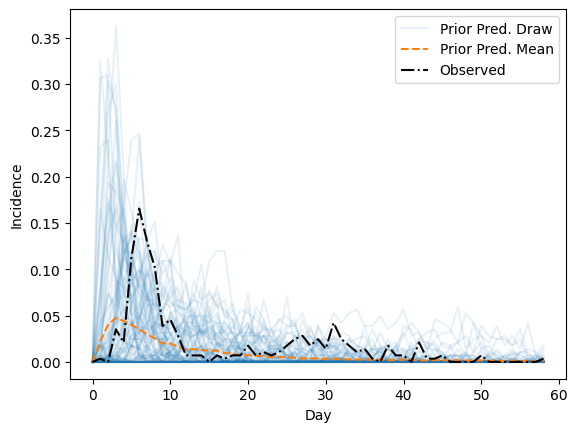

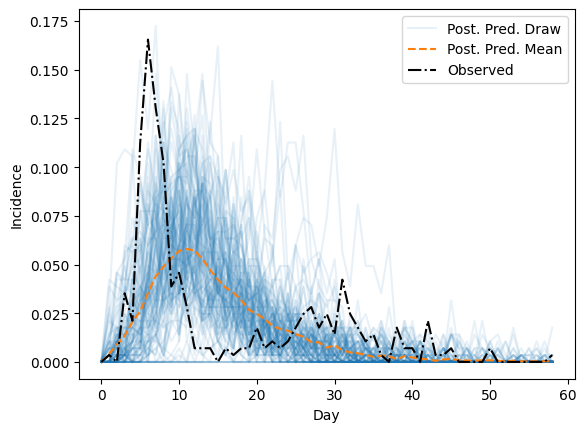

Posterior Estimate of beta:  6.228 (1.245, 16.534)
Posterior Estimate of epsilon:  0.209 (0.074, 0.595)
Posterior Estimate of nu:  0.279 (0.008, 0.858)
Posterior Estimate of rho:  0.991 (0.975, 0.997)


In [21]:
tag = "base"
predictions[tag], estimates[tag] = run_experiment(base_dataset, tag)

# I. 2Vi
Two-virus

In [24]:
beta_1_prior = torch.distributions.Exponential(rate=0.3)
epsilon_prior = torch.distributions.Exponential(rate=2)
nu_prior = torch.distributions.Exponential(rate=2)
rho_prior = torch.distributions.Uniform(low=0.5, high=.99)
gamma_prior = torch.distributions.Exponential(rate=10)
beta_2_prior = torch.distributions.Exponential(rate=0.15)

In [25]:
twovi_dataset = TwoVi(init_I1=3, init_I2=1, init_S=277, beta_1=beta_1_prior, epsilon=epsilon_prior,
                     nu=nu_prior, rho=rho_prior, gamma=gamma_prior, beta_2=beta_2_prior, notebook=True,
                     n_sample=N)
start = time.time()
twovi_dataset.sample_model()
stop = time.time()
print(f"Time to simulate {N:,} samples: {stop - start:.1f}s.")

Simulating samples...
Time to simulate 2,000 samples: 238.0s.


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores

  | Name  | Type     | Params | Mode 
-------------------------------------------
0 | embed | Identity | 0      | train
1 | flow  | MAF      | 36.7 K | train
-------------------------------------------
36.7 K    Trainable params
0         Non-trainable params
36.7 K    Total params
0.147     Total estimated model params size (MB)
33        Modules in train mode
0         Modules in eval mode


Prior Estimate of beta_1:  3.322 (0.169, 9.920)
Prior Estimate of epsilon:  0.488 (0.024, 1.494)
Prior Estimate of nu:  0.493 (0.026, 1.473)
Prior Estimate of rho:  0.746 (0.525, 0.963)
Prior Estimate of gamma:  0.100 (0.005, 0.284)
Prior Estimate of beta_2:  6.724 (0.317, 20.163)


Sanity Checking: |                                                          | 0/? [00:00<?, ?it/s]

Training: |                                                                 | 0/? [00:00<?, ?it/s]

Validation: |                                                               | 0/? [00:00<?, ?it/s]

...

Validation: |                                                               | 0/? [00:00<?, ?it/s]

Validation: |                                                               | 0/? [00:00<?, ?it/s]

Validation: |                                                               | 0/? [00:00<?, ?it/s]

Validation: |                                                               | 0/? [00:00<?, ?it/s]

Validation: |                                                               | 0/? [00:00<?, ?it/s]

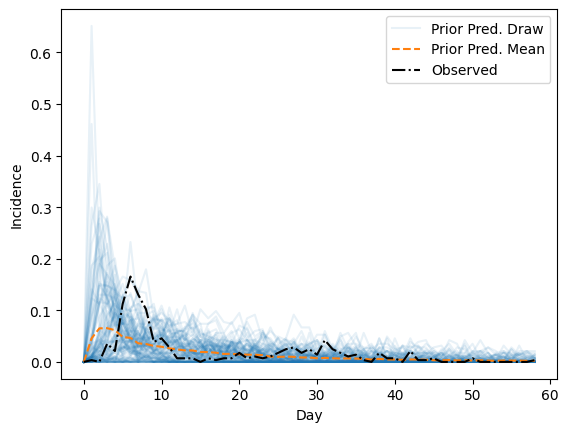

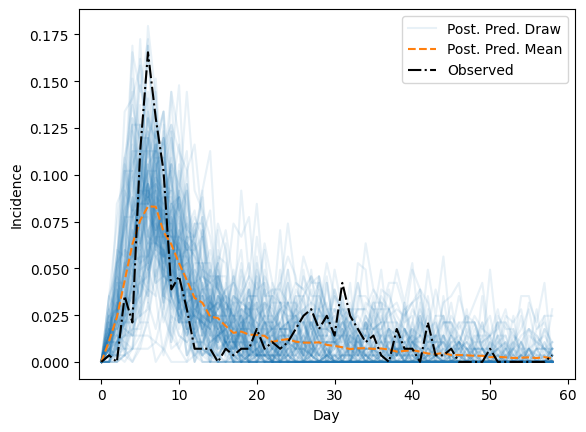

Posterior Estimate of beta_1:  2.211 (0.371, 4.733)
Posterior Estimate of epsilon:  0.374 (0.165, 0.789)
Posterior Estimate of nu:  0.337 (0.038, 0.947)
Posterior Estimate of rho:  0.776 (0.590, 0.942)
Posterior Estimate of gamma:  0.086 (0.007, 0.232)
Posterior Estimate of beta_2:  4.261 (1.197, 8.419)


In [26]:
tag = "2vi"
predictions[tag], estimates[tag] = run_experiment(twovi_dataset, tag)

# II. Mut

In [27]:
beta_prior = torch.distributions.Exponential(rate=0.2)
epsilon_prior = torch.distributions.Exponential(rate=2)
nu_prior = torch.distributions.Exponential(rate=2)
rho_prior = torch.distributions.Uniform(low=0.5, high=.99)
gamma_prior = torch.distributions.Exponential(rate=10)
sigma_prior = torch.distributions.Uniform(low=0.1, high=0.7)
mu_prior = torch.distributions.Uniform(low=0, high=1)

In [28]:
mut_dataset = Mut(init_I=1, init_S=278, n_sample=N, beta=beta_prior, 
                                    epsilon=epsilon_prior, nu=nu_prior, rho=rho_prior, gamma=gamma_prior,
                                    sigma=sigma_prior, mu=mu_prior, notebook=True)
start = time.time()
mut_dataset.sample_model()
stop = time.time()
print(f"Time to simulate {N:,} samples: {stop - start:.1f}s.")

Simulating samples...
Time to simulate 2,000 samples: 165.9s.


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores

  | Name  | Type     | Params | Mode 
-------------------------------------------
0 | embed | Identity | 0      | train
1 | flow  | MAF      | 37.4 K | train
-------------------------------------------
37.4 K    Trainable params
0         Non-trainable params
37.4 K    Total params
0.150     Total estimated model params size (MB)
33        Modules in train mode
0         Modules in eval mode


Prior Estimate of beta:  4.983 (0.253, 14.880)
Prior Estimate of epsilon:  0.488 (0.024, 1.494)
Prior Estimate of nu:  0.493 (0.026, 1.473)
Prior Estimate of rho:  0.746 (0.525, 0.963)
Prior Estimate of gamma:  0.100 (0.005, 0.284)
Prior Estimate of sigma:  0.401 (0.129, 0.670)
Prior Estimate of mu:  0.507 (0.050, 0.953)


Sanity Checking: |                                                          | 0/? [00:00<?, ?it/s]

Training: |                                                                 | 0/? [00:00<?, ?it/s]

Validation: |                                                               | 0/? [00:00<?, ?it/s]

...

Validation: |                                                               | 0/? [00:00<?, ?it/s]

Validation: |                                                               | 0/? [00:00<?, ?it/s]

Validation: |                                                               | 0/? [00:00<?, ?it/s]

Validation: |                                                               | 0/? [00:00<?, ?it/s]

Validation: |                                                               | 0/? [00:00<?, ?it/s]

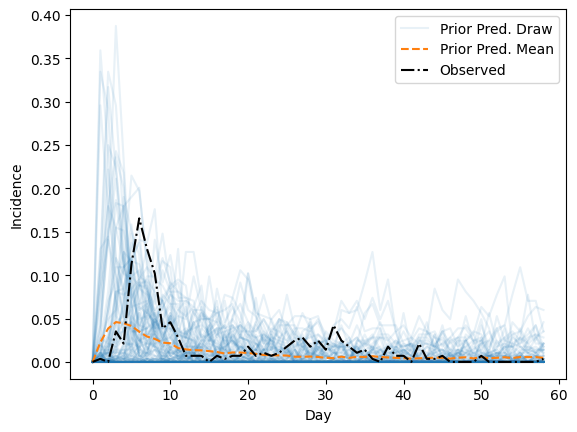

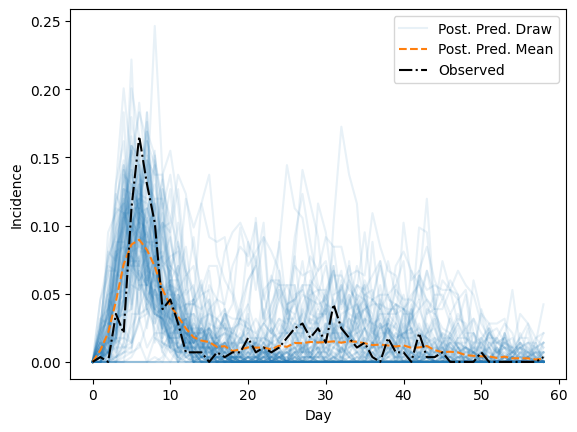

Posterior Estimate of beta:  6.142 (1.982, 14.339)
Posterior Estimate of epsilon:  0.409 (0.149, 0.831)
Posterior Estimate of nu:  0.309 (0.039, 0.796)
Posterior Estimate of rho:  0.768 (0.625, 0.902)
Posterior Estimate of gamma:  0.151 (0.028, 0.392)
Posterior Estimate of sigma:  0.449 (0.122, 0.732)
Posterior Estimate of mu:  0.245 (0.030, 0.578)


In [29]:
tag = "mut"
predictions[tag], estimates[tag] = run_experiment(mut_dataset, tag)

# III. AoN
All-or-nothing

In [30]:
# priors
beta_prior = torch.distributions.Exponential(rate=0.2)
epsilon_prior = torch.distributions.Exponential(rate=2)
nu_prior = torch.distributions.Exponential(rate=2)
rho_prior = torch.distributions.Uniform(low=0.5, high=.99)
gamma_prior = torch.distributions.Exponential(rate=10)
alpha_prior = torch.distributions.Uniform(low=0.1, high=0.9)

In [31]:
aon_dataset = AoN(init_I=1, init_S=277, n_sample=N, beta=beta_prior, 
                                    epsilon=epsilon_prior, nu=nu_prior, rho=rho_prior, gamma=gamma_prior,
                                    alpha=alpha_prior, notebook=True)
start = time.time()
aon_dataset.sample_model()
stop = time.time()
print(f"Time to simulate {N:,} samples: {stop - start:.1f}s.")

Simulating samples...
Time to simulate 2,000 samples: 94.6s.


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores

  | Name  | Type     | Params | Mode 
-------------------------------------------
0 | embed | Identity | 0      | train
1 | flow  | MAF      | 36.7 K | train
-------------------------------------------
36.7 K    Trainable params
0         Non-trainable params
36.7 K    Total params
0.147     Total estimated model params size (MB)
33        Modules in train mode
0         Modules in eval mode


Prior Estimate of beta:  4.983 (0.253, 14.880)
Prior Estimate of epsilon:  0.488 (0.024, 1.494)
Prior Estimate of nu:  0.493 (0.026, 1.473)
Prior Estimate of rho:  0.746 (0.525, 0.963)
Prior Estimate of alpha:  0.500 (0.134, 0.859)
Prior Estimate of gamma:  0.100 (0.005, 0.292)


Sanity Checking: |                                                          | 0/? [00:00<?, ?it/s]

Training: |                                                                 | 0/? [00:00<?, ?it/s]

Validation: |                                                               | 0/? [00:00<?, ?it/s]

...

Validation: |                                                               | 0/? [00:00<?, ?it/s]

Validation: |                                                               | 0/? [00:00<?, ?it/s]

Validation: |                                                               | 0/? [00:00<?, ?it/s]

Validation: |                                                               | 0/? [00:00<?, ?it/s]

Validation: |                                                               | 0/? [00:00<?, ?it/s]

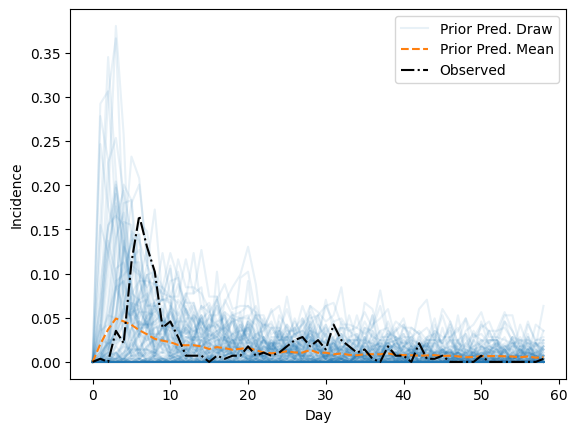

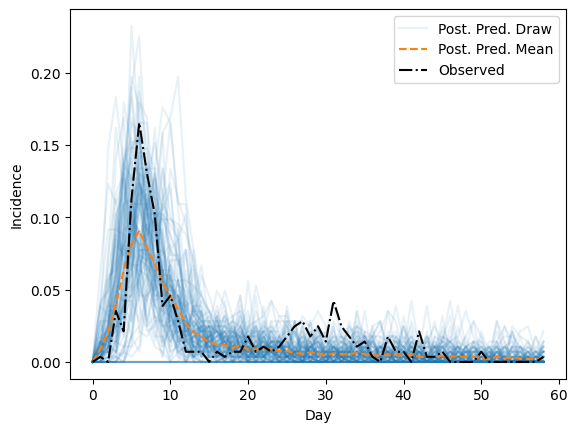

Posterior Estimate of beta:  4.902 (2.020, 10.099)
Posterior Estimate of epsilon:  0.550 (0.162, 1.030)
Posterior Estimate of nu:  0.436 (0.032, 1.517)
Posterior Estimate of rho:  0.726 (0.557, 0.897)
Posterior Estimate of alpha:  0.563 (0.309, 0.767)
Posterior Estimate of gamma:  0.128 (0.025, 0.293)


In [32]:
tag = "aon"
predictions[tag], estimates[tag] = run_experiment(aon_dataset, tag)

# IV. PPI
Partial Protective Immunity

In [33]:
# priors
beta_prior = torch.distributions.Exponential(rate=0.2)
epsilon_prior = torch.distributions.Exponential(rate=2)
nu_prior = torch.distributions.Exponential(rate=2)
rho_prior = torch.distributions.Uniform(low=0.5, high=.99)
gamma_prior = torch.distributions.Exponential(rate=10)
sigma_prior = torch.distributions.Uniform(low=0.1, high=0.7)

In [34]:
ppi_dataset = PPI(init_I=1, init_S=277, n_sample=N, beta=beta_prior, 
                                    epsilon=epsilon_prior, nu=nu_prior, rho=rho_prior, gamma=gamma_prior,
                                    sigma=sigma_prior, notebook=True)
start = time.time()
ppi_dataset.sample_model()
stop = time.time()
print(f"Time to simulate {N:,} samples: {stop - start:.1f}s.")

Simulating samples...
Time to simulate 2,000 samples: 153.9s.


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores

  | Name  | Type     | Params | Mode 
-------------------------------------------
0 | embed | Identity | 0      | train
1 | flow  | MAF      | 36.7 K | train
-------------------------------------------
36.7 K    Trainable params
0         Non-trainable params
36.7 K    Total params
0.147     Total estimated model params size (MB)
33        Modules in train mode
0         Modules in eval mode


Prior Estimate of beta:  4.983 (0.253, 14.880)
Prior Estimate of epsilon:  0.488 (0.024, 1.494)
Prior Estimate of nu:  0.493 (0.026, 1.473)
Prior Estimate of rho:  0.746 (0.525, 0.963)
Prior Estimate of sigma:  0.400 (0.126, 0.669)
Prior Estimate of gamma:  0.100 (0.005, 0.292)


Sanity Checking: |                                                          | 0/? [00:00<?, ?it/s]

Training: |                                                                 | 0/? [00:00<?, ?it/s]

Validation: |                                                               | 0/? [00:00<?, ?it/s]

...

Validation: |                                                               | 0/? [00:00<?, ?it/s]

Validation: |                                                               | 0/? [00:00<?, ?it/s]

Validation: |                                                               | 0/? [00:00<?, ?it/s]

Validation: |                                                               | 0/? [00:00<?, ?it/s]

Validation: |                                                               | 0/? [00:00<?, ?it/s]

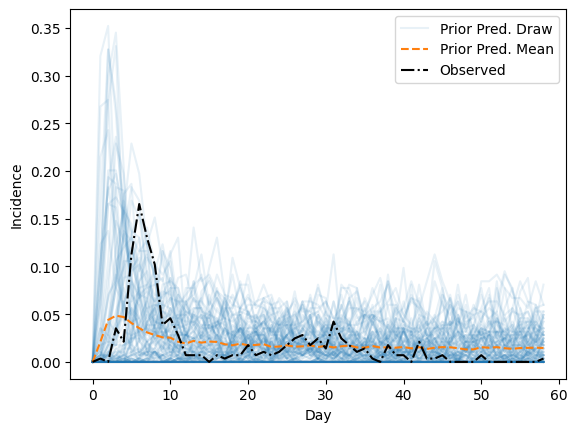

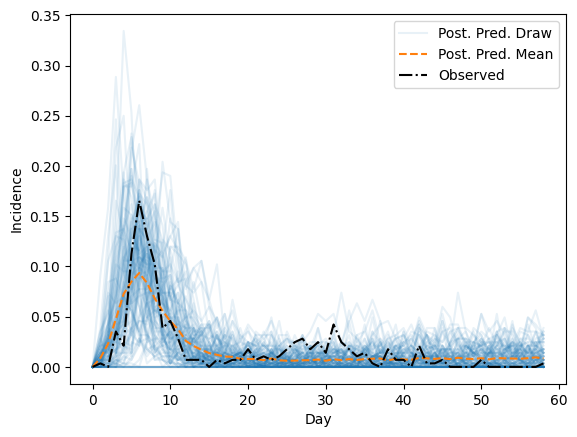

Posterior Estimate of beta:  4.546 (1.558, 11.725)
Posterior Estimate of epsilon:  0.630 (0.213, 1.325)
Posterior Estimate of nu:  0.366 (0.023, 1.231)
Posterior Estimate of rho:  0.773 (0.537, 0.964)
Posterior Estimate of sigma:  0.387 (0.141, 0.682)
Posterior Estimate of gamma:  0.040 (0.008, 0.105)


In [35]:
tag = "ppi"
predictions[tag], estimates[tag] = run_experiment(ppi_dataset, tag)

# V. InH
In-host

In [36]:
beta_prior = torch.distributions.Exponential(rate=0.2)
epsilon_prior = torch.distributions.Exponential(rate=2)
nu_prior = torch.distributions.Exponential(rate=2)
rho_prior = torch.distributions.Uniform(low=0.5, high=.99)
gamma_prior = torch.distributions.Exponential(rate=12)
alpha_prior = torch.distributions.Uniform(low=0.1, high=0.9)

In [37]:
inh_dataset = InH(init_I=1, init_S=277, n_sample=N, beta=beta_prior, 
                                    epsilon=epsilon_prior, nu=nu_prior, rho=rho_prior, gamma=gamma_prior,
                                    alpha=alpha_prior, notebook=True)
start = time.time()
inh_dataset.sample_model()
stop = time.time()
print(f"Time to simulate {N:,} samples: {stop - start:.1f}s.")

Simulating samples...
Time to simulate 2,000 samples: 93.2s.


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores

  | Name  | Type     | Params | Mode 
-------------------------------------------
0 | embed | Identity | 0      | train
1 | flow  | MAF      | 36.7 K | train
-------------------------------------------
36.7 K    Trainable params
0         Non-trainable params
36.7 K    Total params
0.147     Total estimated model params size (MB)
33        Modules in train mode
0         Modules in eval mode


Prior Estimate of beta:  4.983 (0.253, 14.880)
Prior Estimate of epsilon:  0.488 (0.024, 1.494)
Prior Estimate of nu:  0.493 (0.026, 1.473)
Prior Estimate of rho:  0.746 (0.525, 0.963)
Prior Estimate of alpha:  0.500 (0.134, 0.859)
Prior Estimate of gamma:  0.083 (0.005, 0.243)


Sanity Checking: |                                                          | 0/? [00:00<?, ?it/s]

Training: |                                                                 | 0/? [00:00<?, ?it/s]

Validation: |                                                               | 0/? [00:00<?, ?it/s]

...

Validation: |                                                               | 0/? [00:00<?, ?it/s]

Validation: |                                                               | 0/? [00:00<?, ?it/s]

Validation: |                                                               | 0/? [00:00<?, ?it/s]

Validation: |                                                               | 0/? [00:00<?, ?it/s]

Validation: |                                                               | 0/? [00:00<?, ?it/s]

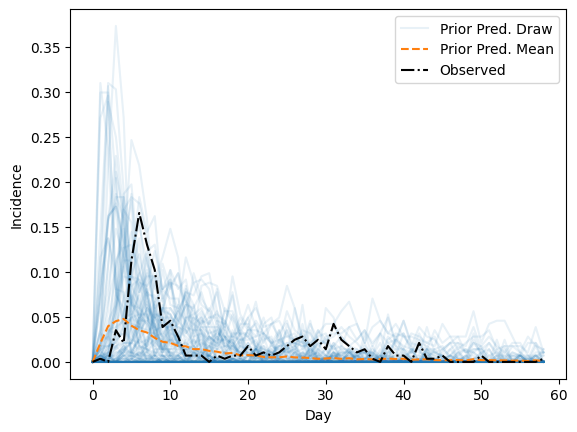

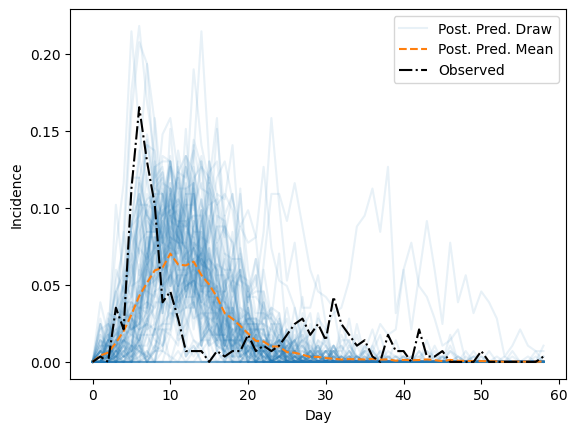

Posterior Estimate of beta:  2.662 (1.272, 4.965)
Posterior Estimate of epsilon:  0.418 (0.157, 0.980)
Posterior Estimate of nu:  0.360 (0.026, 1.212)
Posterior Estimate of rho:  0.983 (0.957, 0.996)
Posterior Estimate of alpha:  0.481 (0.132, 0.841)
Posterior Estimate of gamma:  0.073 (0.003, 0.172)


In [38]:
tag = "inh"
predictions[tag], estimates[tag] = run_experiment(inh_dataset, tag)

# VI. Win
Window-of-reinfection

In [39]:
# priors
beta_prior = torch.distributions.Exponential(rate=0.2)
epsilon_prior = torch.distributions.Exponential(rate=2)
nu_prior = torch.distributions.Exponential(rate=2)
rho_prior = torch.distributions.Uniform(low=0.5, high=.99)
gamma_prior = torch.distributions.Exponential(rate=10)
tau_prior = torch.distributions.Exponential(rate=4)

In [40]:
win_dataset = Win(init_I=1, init_S=277, n_sample=N, beta=beta_prior, 
                                    epsilon=epsilon_prior, nu=nu_prior, rho=rho_prior, gamma=gamma_prior,
                                    tau=tau_prior, notebook=True)
start = time.time()
win_dataset.sample_model()
stop = time.time()
print(f"Time to simulate {N:,} samples: {stop - start:.1f}s.")

Simulating samples...
Time to simulate 2,000 samples: 152.2s.


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores

  | Name  | Type     | Params | Mode 
-------------------------------------------
0 | embed | Identity | 0      | train
1 | flow  | MAF      | 36.7 K | train
-------------------------------------------
36.7 K    Trainable params
0         Non-trainable params
36.7 K    Total params
0.147     Total estimated model params size (MB)
33        Modules in train mode
0         Modules in eval mode


Prior Estimate of beta:  4.983 (0.253, 14.880)
Prior Estimate of epsilon:  0.488 (0.024, 1.494)
Prior Estimate of nu:  0.493 (0.026, 1.473)
Prior Estimate of rho:  0.746 (0.525, 0.963)
Prior Estimate of gamma:  0.100 (0.005, 0.284)
Prior Estimate of tau:  0.252 (0.012, 0.756)


Sanity Checking: |                                                          | 0/? [00:00<?, ?it/s]

Training: |                                                                 | 0/? [00:00<?, ?it/s]

Validation: |                                                               | 0/? [00:00<?, ?it/s]

...

Validation: |                                                               | 0/? [00:00<?, ?it/s]

Validation: |                                                               | 0/? [00:00<?, ?it/s]

Validation: |                                                               | 0/? [00:00<?, ?it/s]

Validation: |                                                               | 0/? [00:00<?, ?it/s]

Validation: |                                                               | 0/? [00:00<?, ?it/s]

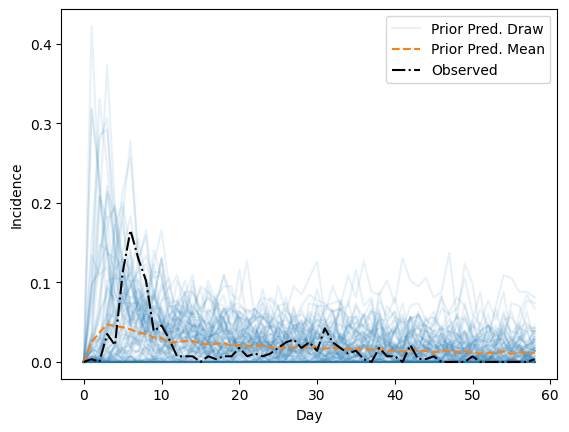

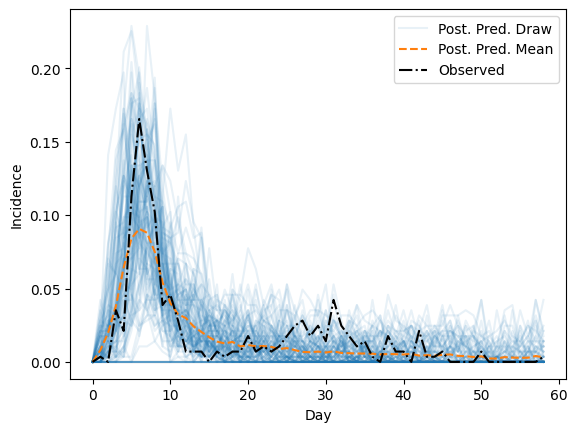

Posterior Estimate of beta:  4.104 (1.890, 8.347)
Posterior Estimate of epsilon:  0.622 (0.225, 1.155)
Posterior Estimate of nu:  0.447 (0.041, 1.377)
Posterior Estimate of rho:  0.754 (0.480, 0.922)
Posterior Estimate of gamma:  0.074 (0.005, 0.199)
Posterior Estimate of tau:  0.330 (0.031, 0.798)


In [41]:
tag = "win"
predictions[tag], estimates[tag] = run_experiment(win_dataset, tag)

## Write Out Results

In [50]:
predictions.items()

dict_items([('base', {'error': (np.float64(0.03357426639838621), np.float64(0.032691892482731896), np.float64(0.03587094108827029)), 'residual mean': np.float64(-0.00318333711490919), 'residual autocorrelation': array([ 0.3655642 ,  0.31970908,  0.22685129,  0.26291191,  0.04444881,
        0.0105936 ,  0.14858008,  0.05371954, -0.09984001, -0.07891633,
        0.01848475, -0.09877458, -0.19091175, -0.27632663, -0.25242285,
       -0.22846769, -0.36538504, -0.30445335, -0.26855909])}), ('2vi', {'error': (np.float64(0.024380195036403138), np.float64(0.025580846562719826), np.float64(0.02597630690145829)), 'residual mean': np.float64(-0.001017545790143185), 'residual autocorrelation': array([ 0.5192774 ,  0.40014523,  0.22409772,  0.13377485,  0.01534872,
       -0.0218728 ,  0.06809466, -0.05170788, -0.10133849, -0.12440147,
        0.01925254, -0.11947378, -0.12993138, -0.24893767, -0.29147501,
       -0.33449744, -0.37168981, -0.30340448, -0.18319883])}), ('mut', {'error': (np.float64

In [51]:
predictions["mut"]

{'error': (np.float64(0.026620840708320905),
  np.float64(0.02678851967316991),
  np.float64(0.03011916533606644)),
 'residual mean': np.float64(-0.00028586757258843574),
 'residual autocorrelation': array([ 0.42764732,  0.27518018,  0.05889868, -0.05027441, -0.10821275,
        -0.19547185, -0.06941536, -0.0654646 , -0.13364699, -0.07802114,
         0.08006392,  0.00396806,  0.04675055, -0.10637959, -0.12149952,
        -0.19537205, -0.19451228, -0.12086446,  0.05424602])}

In [53]:
errors_table = {"Model": [], "Total Error": [], "Second Wave Error": [], "Extinction Period Error": []}
for k, v in predictions.items():
    errors_table["Model"].append(k)
    errors_table["Total Error"].append(v["error"][0])
    errors_table["Second Wave Error"].append(v["error"][1])
    errors_table["Extinction Period Error"].append(v["error"][2])

In [55]:
print(pd.DataFrame(errors_table).to_latex(float_format="{:0.4f}".format, index=False))

\begin{tabular}{lrrr}
\toprule
Model & Total Error & Second Wave Error & Extinction Period Error \\
\midrule
base & 0.0336 & 0.0327 & 0.0359 \\
2vi & 0.0244 & 0.0256 & 0.0260 \\
mut & 0.0266 & 0.0268 & 0.0301 \\
aon & 0.0244 & 0.0257 & 0.0305 \\
ppi & 0.0276 & 0.0324 & 0.0253 \\
inh & 0.0352 & 0.0357 & 0.0374 \\
win & 0.0255 & 0.0267 & 0.0290 \\
\bottomrule
\end{tabular}



In [49]:
with open('results/reinfection_estimates.pkl', 'wb') as f:
    pickle.dump(estimates, f)

with open('results/reinfection_predictions.pkl', 'wb') as f:
    pickle.dump(predictions, f)

# Visualizing the Estimates

In [143]:
key_mapping = {
    "base": "Base", "2vi": "2Vi", "mut": "Mut", "aon": "AoN",
    "ppi": "PPI", "inh": "InH", "win": "Win"
}

['Base', 'Mut', 'AoN', 'PPI', 'InH', 'Win']

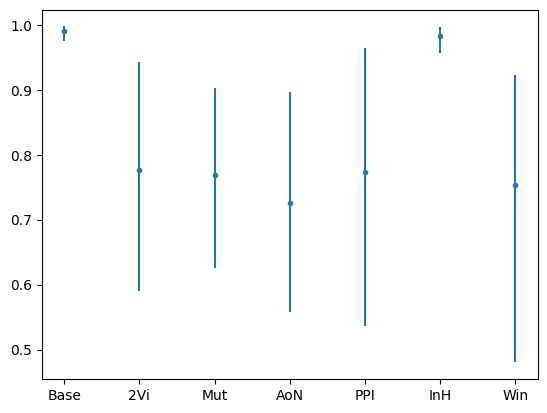

In [148]:
p = "rho"
x = [k for k in estimates.keys() if estimates[k][p]]
y = [estimates[k][p][0] for k in x]
y_low = [estimates[k][p][0] - estimates[k][p][1] for k in x]
y_high = [estimates[k][p][2] - estimates[k][p][0] for k in x]

yerr = np.array([y_low, y_high])

x = [key_mapping.get(item, item) for item in x]
plt.errorbar(x=x, y = y, yerr=yerr, fmt=".")
# plt.ylabel(r"$\rho$")
plt.savefig("figures/estimate_rho.png")
plt.show()

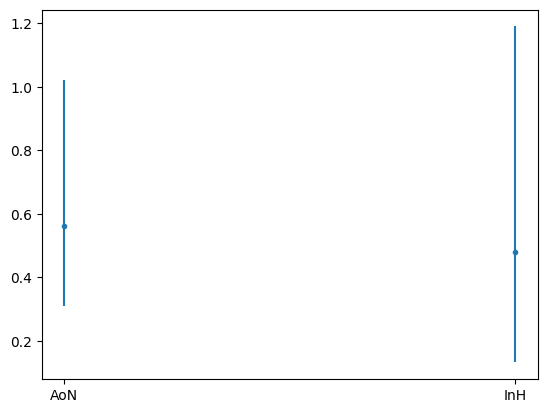

In [149]:
p = "alpha"
x = [k for k in estimates.keys() if estimates[k].get(p)]
est = [estimates[k][p] for k in x]
y = [e[0] for e in est]
y_low = [e[0] - e[1] for e in est]
y_high = [e[2] - e[1] for e in est]
yerr = np.array([y_low, y_high])
x = [key_mapping.get(item, item) for item in x]
plt.errorbar(x, y, yerr=yerr, fmt=".")
plt.savefig("figures/estimate_alpha.png")
plt.show()

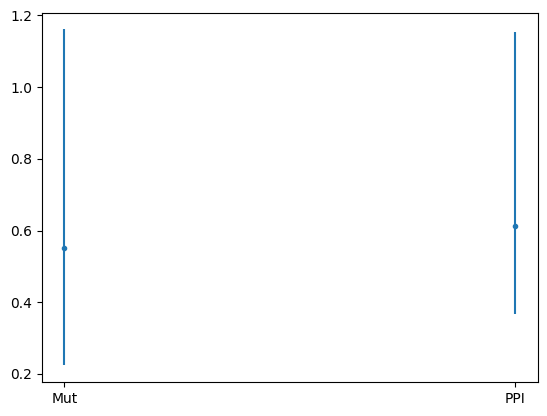

In [150]:
p = "sigma"
x = [k for k in estimates.keys() if estimates[k].get(p)]
est = [estimates[k][p] for k in x]
y = [1 - e[0] for e in est]
y_low = [(1 - e[1]) - (1 - e[0]) for e in est]
y_high = [(1 - e[1]) - (1 - e[2]) for e in est]
yerr = np.array([y_low, y_high])
x = [key_mapping.get(item, item) for item in x]
plt.errorbar(x, y, yerr=yerr, fmt=".")
plt.savefig("figures/estimate_sigma.png")
plt.show()

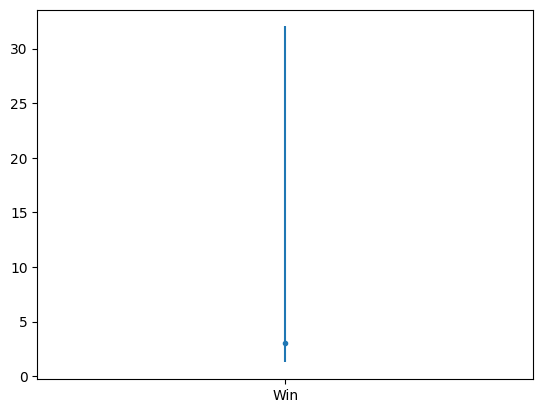

In [151]:
p = "tau"
x = [k for k in estimates.keys() if estimates[k].get(p)]
est = [estimates[k][p] for k in x]
y = [1/e[0] for e in est]
y_high = [(1/e[1]) - (1/e[0]) for e in est]
y_low = [(1/e[0]) - (1/e[2]) for e in est]
yerr = np.array([y_low, y_high])
x = [key_mapping.get(item, item) for item in x]
plt.errorbar(x, y, yerr=yerr, fmt=".")
plt.savefig("figures/estimate_tau.png")
plt.show()

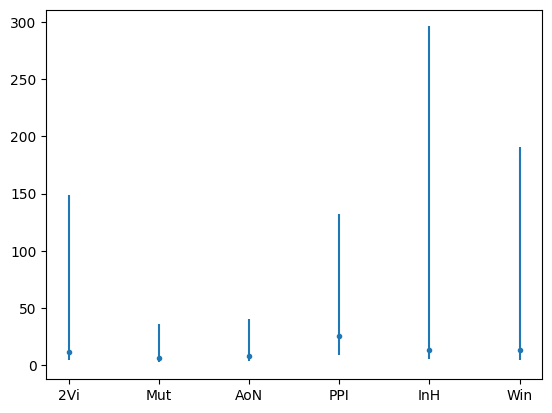

In [152]:
p = "gamma"
x = [k for k in estimates.keys() if estimates[k].get(p)]
est = [estimates[k][p] for k in x]
y = [1/e[0] for e in est]
y_high = [(1/e[1]) - (1/e[0]) for e in est]
y_low = [(1/e[0]) - (1/e[2]) for e in est]
yerr = np.array([y_low, y_high])
x = [key_mapping.get(item, item) for item in x]
plt.errorbar(x, y, yerr=yerr, fmt=".")
plt.savefig("figures/estimate_gamma.png")
plt.show()

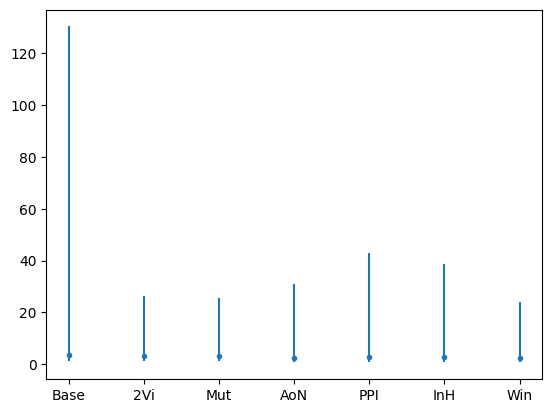

In [154]:
p = "nu"
x = [k for k in estimates.keys() if estimates[k].get(p)]
est = [estimates[k][p] for k in x]
y = [1/e[0] for e in est]
y_high = [(1/e[1]) - (1/e[0]) for e in est]
y_low = [(1/e[0]) - (1/e[2]) for e in est]
yerr = np.array([y_low, y_high])
x = [key_mapping.get(item, item) for item in x]
plt.errorbar(x, y, yerr=yerr, fmt=".")
plt.savefig("figures/estimate_nu.png")
plt.show()

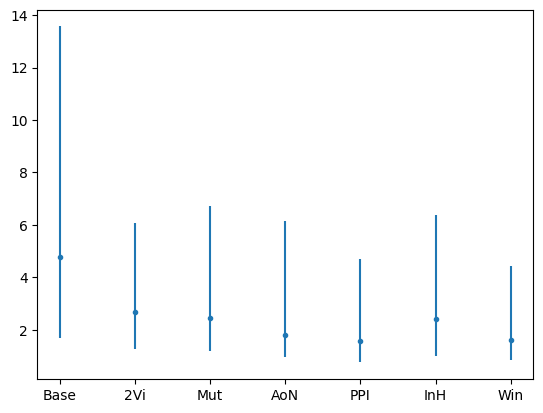

In [155]:
p = "epsilon"
x = [k for k in estimates.keys() if estimates[k].get(p)]
est = [estimates[k][p] for k in x]
y = [1/e[0] for e in est]
y_high = [(1/e[1]) - (1/e[0]) for e in est]
y_low = [(1/e[0]) - (1/e[2]) for e in est]
yerr = np.array([y_low, y_high])
x = [key_mapping.get(item, item) for item in x]
plt.errorbar(x, y, yerr=yerr, fmt=".")
plt.savefig("figures/estimate_epsilon.png")
plt.show()

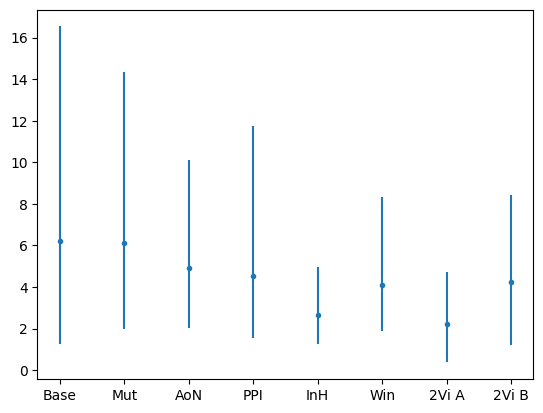

In [156]:
p = "beta"
x = [k for k in estimates.keys() if estimates[k].get(p)]
y = [estimates[k][p][0] for k in x] + [estimates["2vi"]["beta_1"][0], estimates["2vi"]["beta_2"][0]]
y_low = [estimates[k][p][0] - estimates[k][p][1] for k in x] + [estimates["2vi"]["beta_1"][0] - estimates["2vi"]["beta_1"][1], estimates["2vi"]["beta_2"][0] - estimates["2vi"]["beta_2"][1]]
y_high = [estimates[k][p][2] - estimates[k][p][0] for k in x] + [estimates["2vi"]["beta_1"][2] - estimates["2vi"]["beta_1"][0], estimates["2vi"]["beta_2"][2] - estimates["2vi"]["beta_2"][0]]

yerr = np.array([y_low, y_high])
x = [key_mapping.get(item, item) for item in x]
plt.errorbar(x=x+ ["2Vi A", "2Vi B"], y = y, yerr=yerr, fmt=".")
plt.savefig("figures/estimate_beta.png")
plt.show()

In [47]:
predictions

{'base': {'error': {'total': np.float64(0.028963387143148757),
   'second wave': np.float64(0.029563768599084335),
   'extinction': np.float64(0.03100167687434662)},
  'extinction probability': {'second wave': np.float64(0.06363636363636364),
   'first wave': np.float64(0.012222222222222223)},
  'residual mean': np.float64(-0.0030502504792253846),
  'residual autocorrelation': array([ 0.62106315,  0.39086651,  0.12236817, -0.04905355, -0.18062533,
         -0.27932489, -0.23159198, -0.31059446, -0.30357212, -0.27457762,
         -0.10119178, -0.22249079, -0.20140853, -0.21463896, -0.23257261,
         -0.25396437, -0.23918196, -0.13116959,  0.01991133])},
 '2vi': {'error': {'total': np.float64(0.025275106649860924),
   'second wave': np.float64(0.027562944944031588),
   'extinction': np.float64(0.024233616978991776)},
  'extinction probability': {'second wave': np.float64(0.21863636363636363),
   'first wave': np.float64(0.05888888888888889)},
  'residual mean': np.float64(-0.002224874

In [49]:
for k, v in predictions.items():
    print(k)
    print(predictions[k]["extinction probability"])

base
{'second wave': np.float64(0.06363636363636364), 'first wave': np.float64(0.012222222222222223)}
2vi
{'second wave': np.float64(0.21863636363636363), 'first wave': np.float64(0.05888888888888889)}
mut
{'second wave': np.float64(0.48318181818181827), 'first wave': np.float64(0.19111111111111112)}
aon
{'second wave': np.float64(0.2581818181818181), 'first wave': np.float64(0.15444444444444447)}
ppi
{'second wave': np.float64(0.30999999999999994), 'first wave': np.float64(0.14444444444444446)}
inh
{'second wave': np.float64(0.31499999999999995), 'first wave': np.float64(0.2722222222222222)}
win
{'second wave': np.float64(0.29227272727272724), 'first wave': np.float64(0.1688888888888889)}
